# Phân tích Solar Power Generation

**Vai trò:** sinh viên môn Khai phá dữ liệu.  
**Bài toán:** đọc dữ liệu phát điện và thời tiết của 2 nhà máy điện mặt trời, tiền xử lý, huấn luyện mô hình học máy, đánh giá, trực quan hóa và nhận xét kết quả.

Bộ dữ liệu gồm 4 file chính:
- `Plant_1_Generation_Data.csv`, `Plant_2_Generation_Data.csv`: dữ liệu phát điện theo inverter.
- `Plant_1_Weather_Sensor_Data.csv`, `Plant_2_Weather_Sensor_Data.csv`: dữ liệu cảm biến thời tiết theo thời gian.

Mục tiêu dự báo trong notebook này là **tổng AC_POWER của mỗi nhà máy tại từng mốc thời gian 15 phút**.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'datasets'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

## 1. Đọc và giải thích dữ liệu

Dữ liệu generation có các cột chính:
- `DATE_TIME`: thời điểm đo.
- `PLANT_ID`: mã nhà máy.
- `SOURCE_KEY`: mã inverter.
- `DC_POWER`: công suất DC đầu vào inverter.
- `AC_POWER`: công suất AC đầu ra inverter.
- `DAILY_YIELD`: điện năng sinh ra trong ngày.
- `TOTAL_YIELD`: điện năng tích lũy.

Dữ liệu weather có các cột chính:
- `AMBIENT_TEMPERATURE`: nhiệt độ môi trường.
- `MODULE_TEMPERATURE`: nhiệt độ tấm pin.
- `IRRADIATION`: bức xạ mặt trời.

Nhận xét ban đầu: generation là dữ liệu theo từng inverter, còn weather là dữ liệu cảm biến của cả nhà máy. Vì vậy cần tổng hợp generation theo `DATE_TIME` trước khi ghép với weather.

In [2]:
def dataset_path(name):
    path = DATA_DIR / name
    if path.exists():
        return path
    return BASE_DIR / name

def parse_generation_datetime(series, plant_no):
    if plant_no == 1:
        return pd.to_datetime(series, format='%d-%m-%Y %H:%M', errors='coerce')
    return pd.to_datetime(series, errors='coerce')

def load_plant(plant_no):
    gen = pd.read_csv(dataset_path(f'Plant_{plant_no}_Generation_Data.csv'))
    weather = pd.read_csv(dataset_path(f'Plant_{plant_no}_Weather_Sensor_Data.csv'))
    gen['DATE_TIME'] = parse_generation_datetime(gen['DATE_TIME'], plant_no)
    weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'], errors='coerce')
    gen['PLANT_NO'] = plant_no
    weather['PLANT_NO'] = plant_no
    return gen, weather

generation_frames, weather_frames = [], []
for plant_no in [1, 2]:
    gen, weather = load_plant(plant_no)
    generation_frames.append(gen)
    weather_frames.append(weather)

generation = pd.concat(generation_frames, ignore_index=True)
weather = pd.concat(weather_frames, ignore_index=True)

display(generation.head())
display(weather.head())

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_NO
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,1
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,1
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,1
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,1
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,1


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT_NO
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,1
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,1
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,1
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,1
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,1


In [3]:
summary_generation = generation.groupby('PLANT_NO').agg(
    rows=('DATE_TIME', 'size'),
    timestamps=('DATE_TIME', 'nunique'),
    inverters=('SOURCE_KEY', 'nunique'),
    ac_mean=('AC_POWER', 'mean'),
    dc_mean=('DC_POWER', 'mean'),
    zero_ac_ratio=('AC_POWER', lambda s: (s == 0).mean())
).reset_index()

summary_weather = weather.groupby('PLANT_NO').agg(
    rows=('DATE_TIME', 'size'),
    timestamps=('DATE_TIME', 'nunique'),
    ambient_temp_mean=('AMBIENT_TEMPERATURE', 'mean'),
    module_temp_mean=('MODULE_TEMPERATURE', 'mean'),
    irradiation_mean=('IRRADIATION', 'mean'),
    irradiation_max=('IRRADIATION', 'max')
).reset_index()

display(summary_generation)
display(summary_weather)

,PLANT_NO,rows,timestamps,inverters,ac_mean,dc_mean,zero_ac_ratio
0,1,68778,3158,22,307.802752,3147.426211,0.464553
1,2,67698,3259,22,241.277825,246.701961,0.526781


,PLANT_NO,rows,timestamps,ambient_temp_mean,module_temp_mean,irradiation_mean,irradiation_max
0,1,3182,3182,25.531606,31.091015,0.228313,1.221652
1,2,3259,3259,28.069400,32.772408,0.232737,1.098766


## 2. Tiền xử lý dữ liệu

Các bước tiền xử lý:
1. Chuẩn hóa `DATE_TIME` về kiểu thời gian.
2. Gộp dữ liệu generation theo `PLANT_ID`, `PLANT_NO`, `DATE_TIME` để tạo tổng công suất của nhà máy.
3. Ghép dữ liệu generation đã gộp với weather theo `PLANT_ID`, `PLANT_NO`, `DATE_TIME`.
4. Tạo đặc trưng thời gian: giờ, phút, thứ trong tuần, ngày trong năm, tháng.
5. Mã hóa chu kỳ ngày bằng `HOUR_SIN`, `HOUR_COS` vì 23:45 và 00:00 gần nhau về mặt chu kỳ.
6. Loại dòng thiếu weather trước khi huấn luyện.

Nhận xét: dữ liệu ban đêm có nhiều `AC_POWER = 0`, đây không phải lỗi mà là đặc trưng tự nhiên do không có ánh sáng mặt trời.

In [4]:
def aggregate_generation(gen):
    out = gen.groupby(['PLANT_ID', 'PLANT_NO', 'DATE_TIME'], as_index=False).agg(
        DC_POWER_TOTAL=('DC_POWER', 'sum'),
        AC_POWER_TOTAL=('AC_POWER', 'sum'),
        DAILY_YIELD_TOTAL=('DAILY_YIELD', 'sum'),
        TOTAL_YIELD_TOTAL=('TOTAL_YIELD', 'sum'),
        ACTIVE_SOURCE_COUNT=('SOURCE_KEY', 'nunique'),
        ZERO_AC_COUNT=('AC_POWER', lambda s: int((s == 0).sum()))
    )
    out['ZERO_AC_RATIO'] = out['ZERO_AC_COUNT'] / out['ACTIVE_SOURCE_COUNT']
    return out

def add_time_features(df):
    out = df.copy()
    out['HOUR'] = out['DATE_TIME'].dt.hour
    out['MINUTE'] = out['DATE_TIME'].dt.minute
    out['DAYOFWEEK'] = out['DATE_TIME'].dt.dayofweek
    out['DAYOFYEAR'] = out['DATE_TIME'].dt.dayofyear
    out['MONTH'] = out['DATE_TIME'].dt.month
    hour_fraction = out['HOUR'] + out['MINUTE'] / 60
    out['HOUR_SIN'] = np.sin(2 * np.pi * hour_fraction / 24)
    out['HOUR_COS'] = np.cos(2 * np.pi * hour_fraction / 24)
    out['IS_DAYLIGHT'] = out['HOUR'].between(6, 18).astype(int)
    return out

merged_frames = []
for plant_no in [1, 2]:
    gen = generation[generation['PLANT_NO'] == plant_no]
    w = weather[weather['PLANT_NO'] == plant_no].rename(columns={'SOURCE_KEY': 'WEATHER_SENSOR_KEY'})
    gen_agg = aggregate_generation(gen)
    merged = gen_agg.merge(w, on=['PLANT_ID', 'PLANT_NO', 'DATE_TIME'], how='left', validate='one_to_one')
    merged = add_time_features(merged)
    merged_frames.append(merged)

model_data = pd.concat(merged_frames, ignore_index=True).sort_values('DATE_TIME').reset_index(drop=True)
display(model_data.head())
display(model_data.groupby('PLANT_NO').agg(rows=('DATE_TIME', 'size'), missing_weather=('AMBIENT_TEMPERATURE', lambda s: s.isna().sum())))

,PLANT_ID,PLANT_NO,DATE_TIME,DC_POWER_TOTAL,AC_POWER_TOTAL,DAILY_YIELD_TOTAL,TOTAL_YIELD_TOTAL,ACTIVE_SOURCE_COUNT,ZERO_AC_COUNT,ZERO_AC_RATIO,...,MODULE_TEMPERATURE,IRRADIATION,HOUR,MINUTE,DAYOFWEEK,DAYOFYEAR,MONTH,HOUR_SIN,HOUR_COS,IS_DAYLIGHT
0,4135001,1,2020-05-15 00:00:00,0.0,0.0,0.000000,1.435817e+08,21,21,1.0,...,22.857507,0.0,0,0,4,136,5,0.000000,1.000000,0
1,4136001,2,2020-05-15 00:00:00,0.0,0.0,48899.938095,1.418960e+10,22,22,1.0,...,25.060789,0.0,0,0,4,136,5,0.000000,1.000000,0
2,4136001,2,2020-05-15 00:15:00,0.0,0.0,28401.000000,1.418960e+10,22,22,1.0,...,24.421869,0.0,0,15,4,136,5,0.065403,0.997859,0
3,4135001,1,2020-05-15 00:15:00,0.0,0.0,0.000000,1.435817e+08,21,21,1.0,...,22.761668,0.0,0,15,4,136,5,0.065403,0.997859,0
4,4135001,1,2020-05-15 00:30:00,0.0,0.0,0.000000,1.435817e+08,21,21,1.0,...,22.592306,0.0,0,30,4,136,5,0.130526,0.991445,0


,rows,missing_weather
PLANT_NO,,
1,3158,1
2,3259,0


## 3. Trực quan hóa khám phá dữ liệu

Mục tiêu của bước này là xem quan hệ giữa thời gian, thời tiết và công suất phát điện. Kỳ vọng hợp lý là `IRRADIATION` có quan hệ mạnh với `AC_POWER_TOTAL` vì bức xạ mặt trời quyết định lượng điện tạo ra.

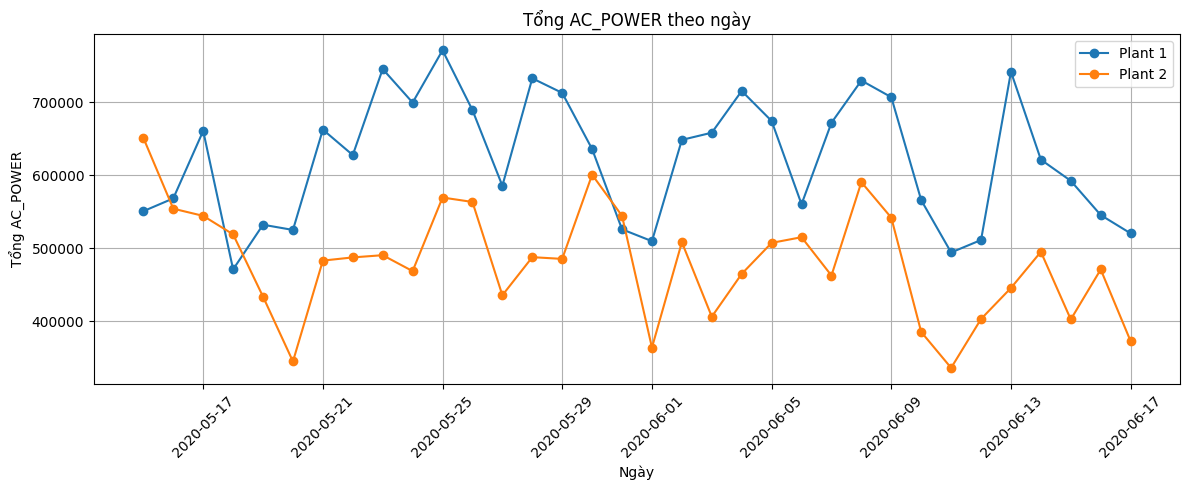

In [5]:
daily_generation = generation.assign(DATE=generation['DATE_TIME'].dt.floor('D')).groupby(['PLANT_NO', 'DATE'], as_index=False).agg(
    AC_POWER_TOTAL=('AC_POWER', 'sum'),
    DC_POWER_TOTAL=('DC_POWER', 'sum')
)

for plant_no, data in daily_generation.groupby('PLANT_NO'):
    plt.plot(data['DATE'], data['AC_POWER_TOTAL'], marker='o', label=f'Plant {plant_no}')
plt.title('Tổng AC_POWER theo ngày')
plt.xlabel('Ngày')
plt.ylabel('Tổng AC_POWER')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

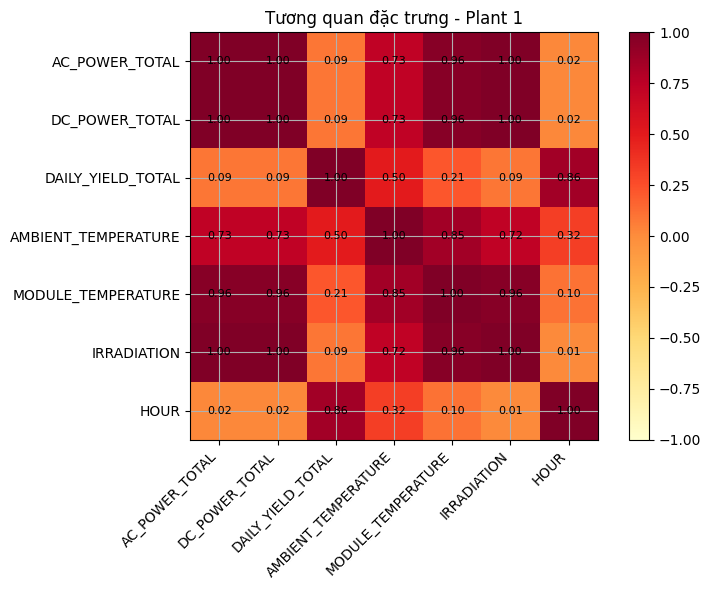

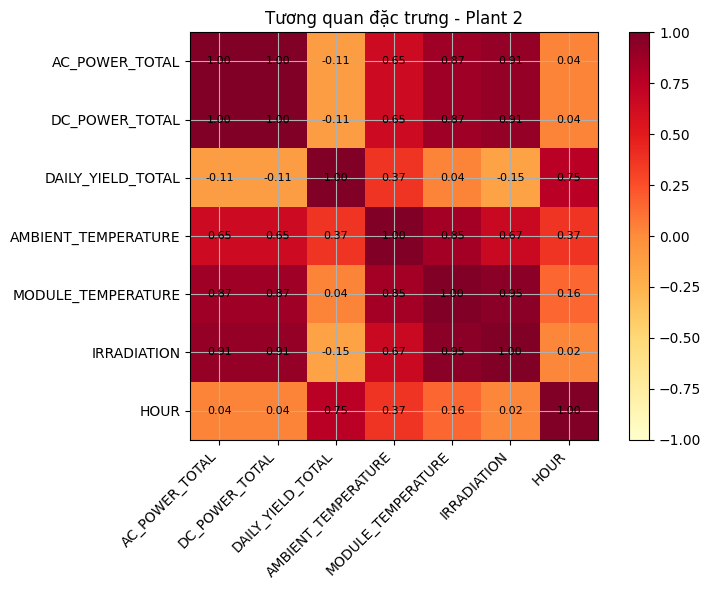

In [6]:
for plant_no in [1, 2]:
    subset = model_data[model_data['PLANT_NO'] == plant_no].dropna(subset=['AMBIENT_TEMPERATURE', 'IRRADIATION'])
    corr_cols = ['AC_POWER_TOTAL', 'DC_POWER_TOTAL', 'DAILY_YIELD_TOTAL', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR']
    corr = subset[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr, cmap='YlOrRd', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_cols)))
    ax.set_xticklabels(corr_cols, rotation=45, ha='right')
    ax.set_yticks(range(len(corr_cols)))
    ax.set_yticklabels(corr_cols)
    ax.set_title(f'Tương quan đặc trưng - Plant {plant_no}')
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## 4. Huấn luyện mô hình học máy

Mô hình được chọn: **Random Forest Regressor**.

Lý do chọn:
- Phù hợp với dữ liệu dạng bảng.
- Bắt được quan hệ phi tuyến giữa bức xạ, nhiệt độ, thời gian và công suất.
- Không cần chuẩn hóa dữ liệu quá phức tạp.
- Có thể xem `feature_importances_` để giải thích đặc trưng quan trọng.

Cách chia dữ liệu: sắp xếp theo thời gian và dùng 80% đầu để train, 20% cuối để test. Cách này phù hợp hơn chia ngẫu nhiên vì dữ liệu là chuỗi thời gian.

In [7]:
model_df = model_data.dropna(subset=['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']).copy()
model_df = model_df.sort_values('DATE_TIME').reset_index(drop=True)

feature_columns = [
    'PLANT_NO', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
    'HOUR', 'MINUTE', 'DAYOFWEEK', 'DAYOFYEAR', 'MONTH',
    'HOUR_SIN', 'HOUR_COS', 'IS_DAYLIGHT'
]
target_column = 'AC_POWER_TOTAL'

split_index = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

numeric_features = [c for c in feature_columns if c != 'PLANT_NO']
categorical_features = ['PLANT_NO']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, max_depth=14, min_samples_leaf=2, random_state=42, n_jobs=1))
])

model.fit(train_df[feature_columns], train_df[target_column])
test_df['PREDICTED_AC_POWER'] = model.predict(test_df[feature_columns])

len(train_df), len(test_df)

(5132, 1284)

## 5. Đánh giá mô hình

Các chỉ số sử dụng:
- **MAE**: sai số tuyệt đối trung bình, càng nhỏ càng tốt.
- **RMSE**: phạt lỗi lớn mạnh hơn MAE, càng nhỏ càng tốt.
- **R²**: mức độ giải thích biến thiên của dữ liệu, càng gần 1 càng tốt.

In [8]:
def metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

rows = []
rows.append({'scope': 'overall', **metrics(test_df[target_column], test_df['PREDICTED_AC_POWER'])})
for plant_no in [1, 2]:
    subset = test_df[test_df['PLANT_NO'] == plant_no]
    rows.append({'scope': f'plant_{plant_no}', **metrics(subset[target_column], subset['PREDICTED_AC_POWER'])})

metrics_df = pd.DataFrame(rows)
display(metrics_df)

,scope,MAE,RMSE,R2
0,overall,501.153261,1397.339167,0.958760
1,plant_1,257.740054,531.902718,0.995483
2,plant_2,743.809352,1901.841140,0.881824


Nhận xét đánh giá:
- Mô hình đạt R² tổng thể khoảng 0.96, cho thấy mô hình giải thích tốt biến động công suất AC.
- Plant 1 có R² cao hơn Plant 2, nghĩa là dữ liệu Plant 1 dễ dự đoán hơn hoặc ổn định hơn.
- Plant 2 có MAE/RMSE lớn hơn, có thể do công suất biến động mạnh hơn, nhiễu nhiều hơn hoặc quan hệ giữa thời tiết và công suất phức tạp hơn.

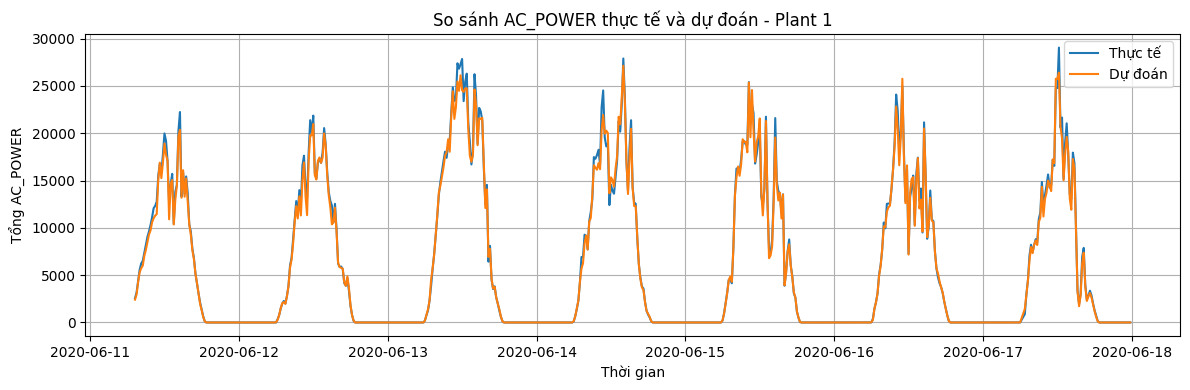

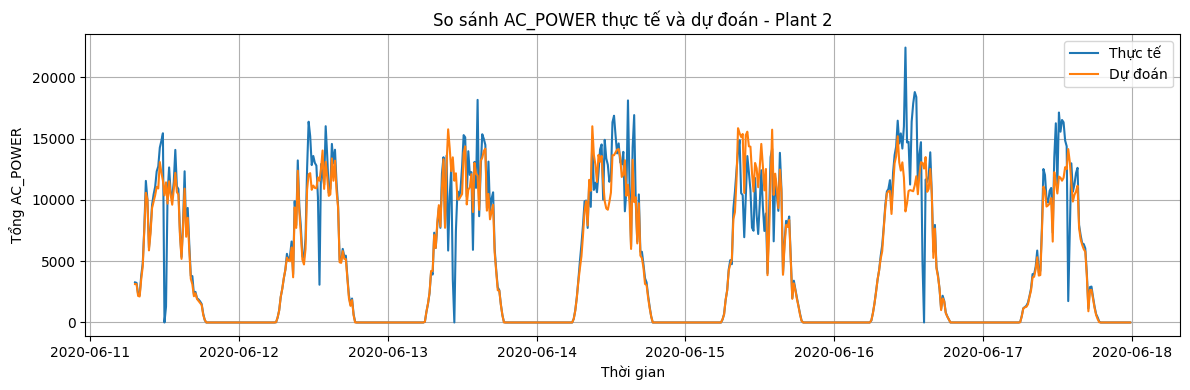

In [9]:
for plant_no in [1, 2]:
    subset = test_df[test_df['PLANT_NO'] == plant_no]
    plt.figure(figsize=(12, 4))
    plt.plot(subset['DATE_TIME'], subset['AC_POWER_TOTAL'], label='Thực tế', linewidth=1.5)
    plt.plot(subset['DATE_TIME'], subset['PREDICTED_AC_POWER'], label='Dự đoán', linewidth=1.5)
    plt.title(f'So sánh AC_POWER thực tế và dự đoán - Plant {plant_no}')
    plt.xlabel('Thời gian')
    plt.ylabel('Tổng AC_POWER')
    plt.legend()
    plt.tight_layout()
    plt.show()

,feature,importance
2,num__IRRADIATION,0.928827
12,cat__PLANT_NO_2,0.024210
11,cat__PLANT_NO_1,0.019279
6,num__DAYOFYEAR,0.011237
5,num__DAYOFWEEK,0.003624
0,num__AMBIENT_TEMPERATURE,0.003535
1,num__MODULE_TEMPERATURE,0.003025
8,num__HOUR_SIN,0.002696
9,num__HOUR_COS,0.001798
7,num__MONTH,0.000788


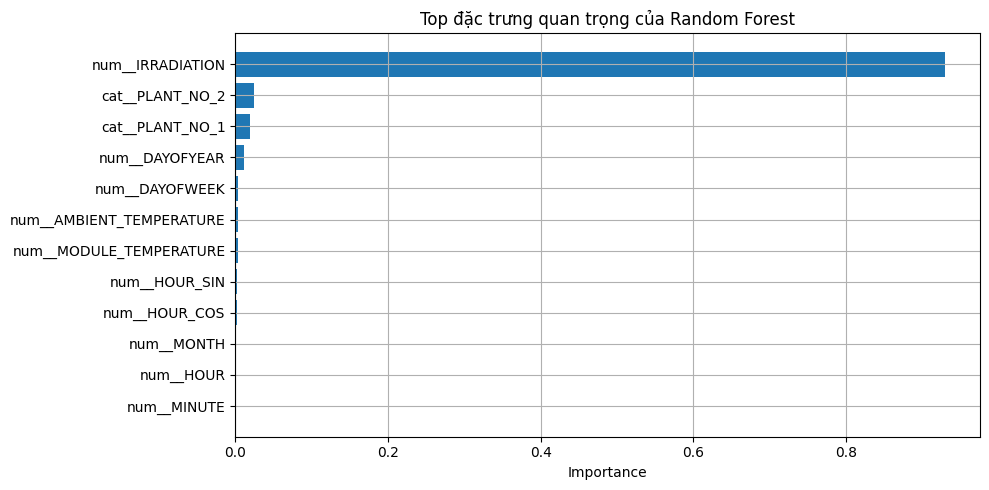

In [10]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out(feature_columns)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(12))

top = importance_df.head(12).sort_values('importance')
plt.figure(figsize=(10, 5))
plt.barh(top['feature'], top['importance'])
plt.title('Top đặc trưng quan trọng của Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Kết luận

Qua quá trình khai phá dữ liệu có thể rút ra:
- `IRRADIATION` là đặc trưng quan trọng nhất để dự báo công suất phát điện mặt trời.
- Các đặc trưng thời gian giúp mô hình phân biệt ban ngày/ban đêm và quy luật chu kỳ trong ngày.
- Random Forest cho kết quả tốt với dữ liệu dạng bảng, đặc biệt ở Plant 1.
- Sai số ở Plant 2 cao hơn, nên nếu cải tiến có thể huấn luyện riêng mô hình cho từng nhà máy, bổ sung đặc trưng trễ theo thời gian hoặc thử các mô hình chuỗi thời gian như Gradient Boosting/LSTM.

